In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from time import time
from lib.Co_withExclusion import simulation, mul_sim_last
from numba import njit, prange
from typing import Tuple
from scipy.optimize import curve_fit
import pickle

In [2]:
@njit
def new_simulation(L: int, T: float, kon: float, koff: float, kstep: float, kq: float, q: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    # grid_kinesins = np.zeros(L) # If there is a kinesin on that side.
    # grid_sides = np.zeros(L) # If side is activated or not.

    propensities = np.zeros(4*L)
    propensities[:L] = kon
    # propensities[0]=0
    # propensities[L]=0
    # propensities[2*L]=0
    # propensities[3*L]=0
    # propensities[L-1]=0
    # propensities[2*L-1]=koff
    # propensities[3*L-1]=0
    # propensities[4*L-1]=0

    theo_dt =  (1 / L*(q*kon+koff+kstep+kq))* np.log(1.01)
    theo_iter = int(T/theo_dt)
    res = np.zeros(theo_iter)
    dts = np.zeros(theo_iter)

    period = 0.1
    blocks = int(T / period)

    i = 0
    t = 0
    block = 0
    next_write_time = period
    DATA = np.zeros((blocks, L))
    TIMES = np.zeros(blocks)

    # print(DATA.shape)
    while t<T:

        S = np.cumsum(propensities)
        r1 = np.random.uniform()
        r2 = S[-1]*np.random.random()

        dt = (1 / S[-1]) * np.log(1 / r1)
        index = np.searchsorted(S, r2, side='right')
        action = index//L
        side = index%L
        front = (side+1)%L
        ffront = (side+2)%L
        back = (side-1)%L

        if action==0:
            propensities[side] = 0
            propensities[L + side] = koff
            propensities[2*L + back] = 0
            propensities[2*L + side] = (1 - propensities[L + front]/koff)* kstep 
            propensities[3*L + side] = 0


        elif action==1:
            propensities[side] = q*kon
            propensities[L + side] = 0
            propensities[2*L + side] = 0
            propensities[2*L + back] = kstep* (propensities[L + back])/koff
            propensities[3*L + side] = kq


        elif action==2:
            propensities[side] = q*kon
            propensities[front] = 0
            propensities[L + side] = 0 
            propensities[L + front] = koff 
            propensities[2*L + back] = kstep* (propensities[L + back])/koff
            propensities[2*L + side] = 0
            propensities[2*L + front] = (1 - propensities[L + ffront]/koff)* kstep 
            propensities[3*L + side] = kq
            propensities[3*L + front] = 0

        else:
            propensities[side] = kon
            propensities[3*L + side] = 0
        
        # propensities[0]=0
        # propensities[L]=0
        # propensities[2*L]=0
        # propensities[3*L]=0
        # propensities[L-1]=0
        # propensities[2*L-1]=koff
        # propensities[3*L-1]=0
        # propensities[4*L-1]=0
        
        
        if next_write_time < t:
            DATA[block, :] = (propensities[:L]==0)
            TIMES[block] = t
            block += 1
            next_write_time += period

        

        if i==theo_iter:
            new_elements = np.zeros(int(theo_iter*(T/t)))
            res = np.concatenate((res, new_elements))
            dts = np.concatenate((dts, new_elements))

        res[i] = action
        dts[i] = dt
        t+=dt
     
        i+=1

    return DATA[:block], TIMES[:block], res[:i], dts[:i]
        

In [3]:
def exponential_func(x, a, b):
    return a * np.exp(-b * x)

def get_binding_data(res, dt):
    dt_sum = np.cumsum(dt)
    a=np.where(res==0)[0]
    Dt = dt_sum[a]
    Diff = Dt[1:]-Dt[:-1]
    return Diff

def get_stepping_data(res, dt):
    dt_sum = np.cumsum(dt)
    a=np.where(res==2)[0]
    Dt = dt_sum[a]
    Diff = Dt[1:]-Dt[:-1]
    return Diff

def fit (res, dt, func):   
    hist, bins = np.histogram(func(res, dt), bins=1000, density=True) 
    bin_centers = (bins[:-1] + bins[1:]) / 2
    params, covariance = curve_fit(exponential_func, bin_centers, hist)
    return params[1]


In [4]:
q=1

L = 300
T = 100
kon = 1
koff = 1
kstep = 100
kq = 10

In [5]:
data, times, res, dt = new_simulation(10,2, kon, koff, kstep, kq, q)

: 

In [ ]:
Q = [8,3,1]
for i, q in enumerate(Q):
    print(q)
    data, times, res, dt = new_simulation(L,T, kon, koff, kstep, kq, q)
    

: 

In [22]:
N=50
Q = np.linspace(1.4,10,N)
print(Q)

[ 1.4         1.5755102   1.75102041  1.92653061  2.10204082  2.27755102
  2.45306122  2.62857143  2.80408163  2.97959184  3.15510204  3.33061224
  3.50612245  3.68163265  3.85714286  4.03265306  4.20816327  4.38367347
  4.55918367  4.73469388  4.91020408  5.08571429  5.26122449  5.43673469
  5.6122449   5.7877551   5.96326531  6.13877551  6.31428571  6.48979592
  6.66530612  6.84081633  7.01632653  7.19183673  7.36734694  7.54285714
  7.71836735  7.89387755  8.06938776  8.24489796  8.42040816  8.59591837
  8.77142857  8.94693878  9.12244898  9.29795918  9.47346939  9.64897959
  9.8244898  10.        ]


In [23]:
lamda = np.zeros(N)
num_kins = np.zeros(N)

In [24]:
for i,q in enumerate(Q):
    data, times, res, dt = new_simulation(L,T, kon, koff, kstep, kq, q)
    num_kins[i] = np.mean(np.sum(data[200:, :], axis=1))
    lamda[i] = fit(res, dt, get_stepping_data)

In [26]:
# with open("cyclic_res", "wb") as f:
#     pickle.dump({"Q":Q, "num_kins":num_kins, "lamda":lamda}, f)

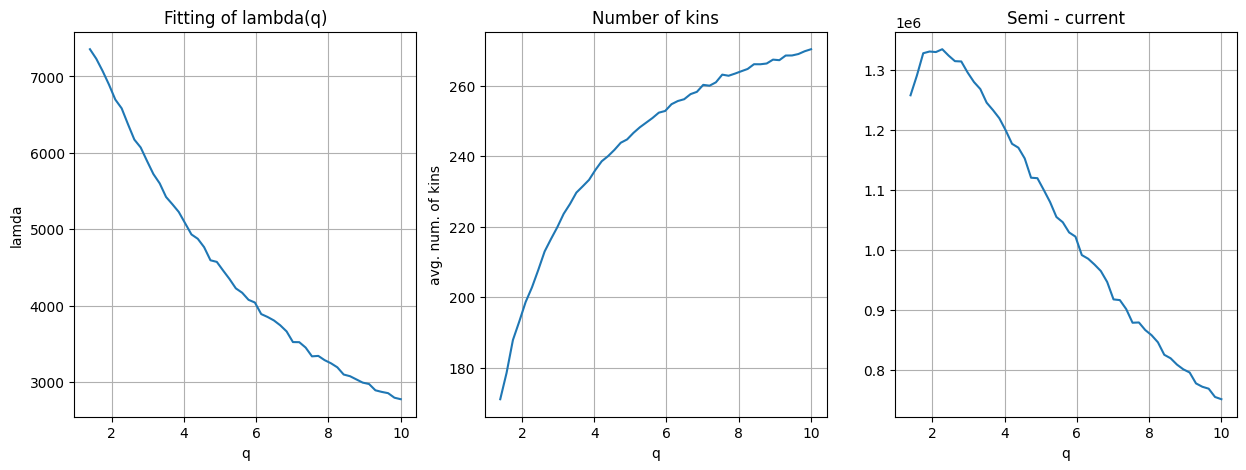

In [25]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))

ax1.plot(Q, lamda)
ax1.set(xlabel = "q", ylabel = "lamda", title = "Fitting of lambda(q)")
ax1.grid()

ax2.plot(Q, num_kins)
ax2.set(xlabel = "q", ylabel = "avg. num. of kins", title = "Number of kins")
ax2.grid()


ax3.plot(Q, num_kins*lamda)
ax3.set(xlabel = "q", ylabel = "", title = "Semi - current")
ax3.grid()